In [40]:
import json
import os
from selenium import webdriver
from selenium.webdriver.chrome.service import Service as ChromeService
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

options = Options()
options.set_capability(
    "goog:loggingPrefs", {"performance": "ALL", "browser": "ALL"}
)

driver_path = ChromeDriverManager().install()

print("Caminho retornado pelo manager:", driver_path)

if not driver_path.endswith(".exe"):
    base_dir = os.path.dirname(driver_path)
    corrected_path = os.path.join(base_dir, "chromedriver.exe")
    
    if os.path.exists(corrected_path):
        print("Caminho corrigido:", corrected_path)
        driver_path = corrected_path
    else:
        raise FileNotFoundError("chromedriver.exe não encontrado na pasta!")

service = ChromeService(driver_path)
driver = webdriver.Chrome(service=service, options=options)



Caminho retornado pelo manager: C:\Users\Pichau\.wdm\drivers\chromedriver\win64\146.0.7680.165\chromedriver-win32/THIRD_PARTY_NOTICES.chromedriver
Caminho corrigido: C:\Users\Pichau\.wdm\drivers\chromedriver\win64\146.0.7680.165\chromedriver-win32\chromedriver.exe


In [41]:
driver.set_page_load_timeout(10)

try:
    driver.get("https://www.sofascore.com/pt/football/match/brazil-croatia/pUbsYUb#id:10230640,tab:statistics")
except:
    pass


driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")

In [42]:
logs_raw = driver.get_log("performance")
logs = [json.loads(lr["message"])["message"] for lr in logs_raw]

In [43]:
for x in logs:
    if 'shotmap' in x['params'].get('headers', {}).get(':path', ''):
        print(x['params'].get('headers', {}).get(':path'))
        break

/api/v1/event/10230640/shotmap


In [44]:
test = json.loads(driver.execute_cdp_cmd('Network.getResponseBody', {'requestId': x["params"]["requestId"]})['body'])['shotmap']
test[0]

{'player': {'name': 'Marquinhos',
  'slug': 'marquinhos',
  'shortName': 'Marquinhos',
  'position': 'D',
  'jerseyNumber': '5',
  'userCount': 36952,
  'gender': 'M',
  'id': 155995,
  'fieldTranslations': {'nameTranslation': {'ar': 'ماركينيوس',
    'bn': 'মারকুইনহোস',
    'hi': 'मार्क्विन्होस'},
   'shortNameTranslation': {'ar': 'ماركينيوس',
    'bn': 'মারকুইনহোস',
    'hi': 'मार्क्विन्होस'}}},
 'isHome': False,
 'shotType': 'post',
 'situation': 'shootout',
 'shootoutOrder': 4,
 'playerCoordinates': {'x': 11.5, 'y': 50, 'z': 0},
 'bodyPart': 'right-foot',
 'goalMouthLocation': 'left',
 'goalMouthCoordinates': {'x': 0, 'y': 55.2, 'z': 3.2},
 'xg': 0.7884,
 'id': 1515382,
 'time': 126,
 'timeSeconds': 7520,
 'draw': {'start': {'x': 50, 'y': 11.5},
  'end': {'x': 44.8, 'y': 0},
  'goal': {'x': 44.8, 'y': 96.8}},
 'reversedPeriodTime': 10,
 'reversedPeriodTimeSeconds': 580,
 'periodTimeSeconds': 320,
 'incidentType': 'shot'}

In [45]:
brasil_shots = [s for s in test if s['isHome'] == False]


In [46]:
goals = [s for s in brasil_shots if s['shotType'] == 'goal']
others = [s for s in brasil_shots if s['shotType'] != 'goal']


In [47]:
import pandas as pd

df = pd.json_normalize(brasil_shots)

df.head()


,isHome,shotType,situation,shootoutOrder,bodyPart,goalMouthLocation,xg,id,time,timeSeconds,...,xgot,player.firstName,player.lastName,blockCoordinates.x,blockCoordinates.y,blockCoordinates.z,draw.block.x,draw.block.y,addedTime,player.sofascoreId
0,False,post,shootout,4.0,right-foot,left,0.78840,1515382,126,7520,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,False,goal,shootout,3.0,right-foot,low-centre,0.78840,1515380,124,7427,...,0.9448,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,False,goal,shootout,2.0,right-foot,low-left,0.78840,1515378,123,7336,...,0.9899,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,False,save,shootout,1.0,right-foot,low-right,0.78840,1515376,121,7245,...,0.9664,NaN,NaN,0.3,50.0,0.0,50.0,0.3,NaN,NaN
4,False,save,set-piece,NaN,left-foot,low-centre,0.13275,1515369,120,7279,...,0.0221,,,0.2,45.5,0.0,45.5,0.2,2.0,NaN


In [48]:
cols = [
    'player.name',
    'player.id',
    'isHome',
    'shotType',
    'situation',
    'time',
    'bodyPart',
    'playerCoordinates.x',
    'playerCoordinates.y',
    'goalMouthCoordinates.y',
    'goalMouthCoordinates.z',
    'periodTimeSeconds',
    'xg',
    'xgot'
]

df = df[cols]
df.head()


,player.name,player.id,isHome,shotType,situation,time,bodyPart,playerCoordinates.x,playerCoordinates.y,goalMouthCoordinates.y,goalMouthCoordinates.z,periodTimeSeconds,xg,xgot
0,Marquinhos,155995,False,post,shootout,126,right-foot,11.5,50.0,55.2,3.2,320,0.78840,NaN
1,Pedro,840219,False,goal,shootout,124,right-foot,11.5,50.0,51.2,3.2,227,0.78840,0.9448
2,Casemiro,122951,False,goal,shootout,123,right-foot,11.5,50.0,53.9,13.9,136,0.78840,0.9899
3,Rodrygo,910536,False,save,shootout,121,right-foot,11.5,50.0,47.5,12.7,45,0.78840,0.9664
4,Casemiro,122951,False,save,set-piece,120,left-foot,4.7,38.8,49.7,12.7,79,0.13275,0.0221


In [49]:
df.columns = [
    'player',
    'player_id',
    'is_home',
    'shot_result',
    'situation',
    'time',
    'body_part',
    'x',
    'y',
    'goal_y',
    'goal_z',
    'time_seconds',
    'xG',
    'xGOT'
]


In [50]:
df = df[df["situation"] != "shootout"]
df

,player,player_id,is_home,shot_result,situation,time,body_part,x,y,goal_y,goal_z,time_seconds,xG,xGOT
4,Casemiro,122951,False,save,set-piece,120,left-foot,4.7,38.8,49.7,12.7,79,0.132750,0.0221
5,Marquinhos,155995,False,block,set-piece,120,head,8.4,45.3,52.4,19.0,77,0.077921,NaN
6,Neymar,124712,False,goal,assisted,105,right-foot,2.6,56.9,48.1,29.7,35,0.699765,0.9501
7,Danilo,124992,False,miss,assisted,105,right-foot,23.1,30.1,39.2,80.6,848,0.019596,NaN
8,Pedro,840219,False,save,assisted,101,right-foot,13.7,44.3,50.7,15.2,641,0.167926,0.0272
9,Pedro,840219,False,miss,corner,92,head,6.3,55.8,98.7,15.3,76,0.125369,NaN
10,Antony,958380,False,save,assisted,90,left-foot,23.8,69.7,49.3,7.0,215,0.017982,0.0243
11,Éder Militão,822519,False,block,regular,86,left-foot,14.1,60.9,53.2,19.0,2424,0.051471,NaN
12,Éder Militão,822519,False,block,assisted,86,right-foot,16.4,64.1,45.8,19.0,2422,0.040442,NaN
13,Richarlison,840217,False,miss,assisted,82,head,11.2,52.1,50.6,69.4,2213,0.046576,NaN


In [51]:
from mplsoccer import VerticalPitch

In [52]:
total_shots = df.shape[0]
total_goals = df[df['shot_result'] == 'goal'].shape[0]
total_xG = df['xG'].sum()
xG_per_shot = total_xG / total_shots
points_average_distance = df['x'].mean()
actual_average_distance = 120 - (df['x'] * 1.2).mean()

sot = 0

for shot in df['shot_result']:
    if shot == 'goal' or shot == 'save':
        sot += 1





In [62]:
background_color = "#006E2E"
yellow = "#f8c100"

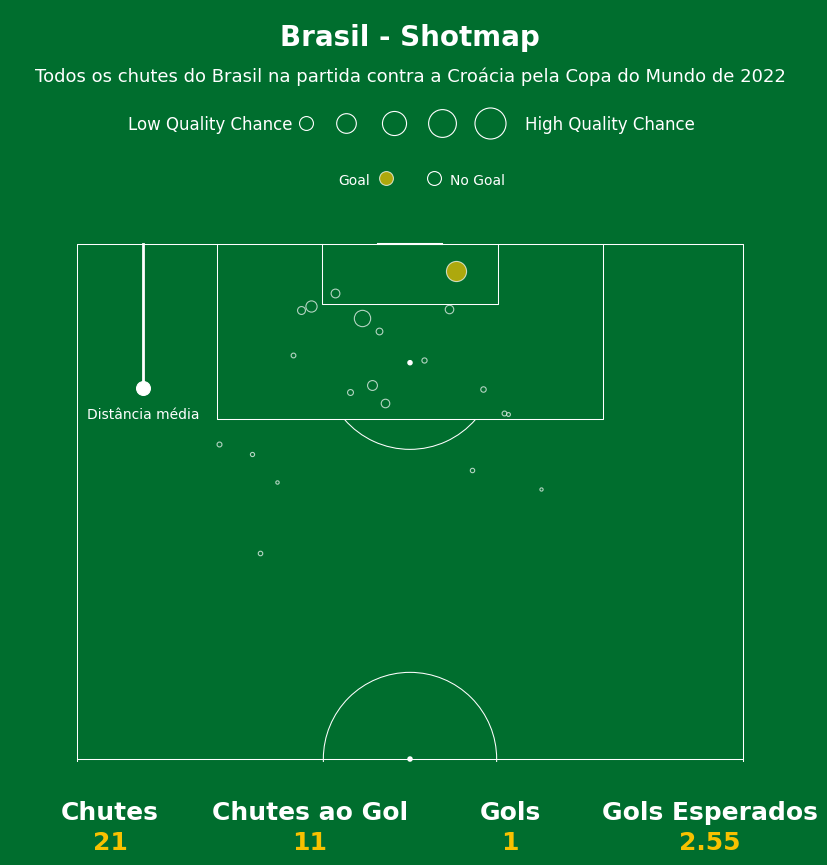

In [65]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,12))
fig.patch.set_facecolor(background_color)

ax1 = fig.add_axes([0,.7,1,.2])
ax1.set_facecolor(background_color)
ax1.set_xlim(0,1)
ax1.set_ylim(0,1)

ax1.text(
    x=0.5,
    y=0.85,
    s="Brasil - Shotmap",
    color="white", 
    fontsize=20,
    ha="center", 
    fontweight="bold"
    )

ax1.text(
    x=0.5,
    y=0.7,
    s="Todos os chutes do Brasil na partida contra a Croácia pela Copa do Mundo de 2022",
    color="white", 
    fontsize=13,
    ha="center", 
    )


ax1.text(
    x=0.25, 
    y=0.5, 
    s=f'Low Quality Chance', 
    fontsize=12, 
    color='white', 
    ha='center'
)

ax1.scatter(
    x=0.37, 
    y=0.53, 
    s=100, 
    color=background_color, 
    edgecolor='white', 
    linewidth=.8
)
ax1.scatter(
    x=0.42, 
    y=0.53, 
    s=200, 
    color=background_color, 
    edgecolor='white', 
    linewidth=.8
)
ax1.scatter(
    x=0.48, 
    y=0.53, 
    s=300, 
    color=background_color, 
    edgecolor='white', 
    linewidth=.8
)
ax1.scatter(
    x=0.54, 
    y=0.53, 
    s=400, 
    color=background_color, 
    edgecolor='white', 
    linewidth=.8
)
ax1.scatter(
    x=0.6, 
    y=0.53, 
    s=500, 
    color=background_color, 
    edgecolor='white', 
    linewidth=.8
)

ax1.text(
    x=0.75, 
    y=0.5, 
    s=f'High Quality Chance', 
    fontsize=12, 
    color='white', 
    ha='center'
)


ax1.text(
    x=0.45, 
    y=0.27, 
    s=f'Goal', 
    fontsize=10,  
    color='white', 
    ha='right'
)
ax1.scatter(
    x=0.47, 
    y=0.3, 
    s=100, 
    color=yellow, 
    edgecolor='white', 
    linewidth=.8,
    alpha=.7
)


ax1.scatter(
    x=0.53, 
    y=0.3, 
    s=100, 
    color=background_color, 
    edgecolor='white', 
    linewidth=.8
)

ax1.text(
    x=0.55, 
    y=0.27, 
    s=f'No Goal', 
    fontsize=10,  
    color='white', 
    ha='left'
)



ax2 = fig.add_axes([.05,.25,.9,.5])
ax2.set_facecolor(background_color)

pitch = VerticalPitch(
    pitch_type='opta',
    pitch_color=background_color,
    half=True,
    pad_bottom=.5,
    line_color='white',
    linewidth=.75,
    axis=True,
    label=True

)

pitch.draw(ax=ax2)

ax2.scatter(
    x=90,
    y=100 - points_average_distance,
    s=100,
    color='white',
    linewidth=.8,
)

ax2.plot(
    [90, 90], 
    [100, 100 - points_average_distance], 
    color='white', 
    linewidth=2
)

ax2.text(
    x=90, 
    y=100 - points_average_distance - 3, 
    s=f'Distância média', 
    fontsize=10, 
    color='white', 
    ha='center'
)

for x in df.to_dict('records'):
    pitch.scatter(
        x=100 - x['x'],
        y=100 - x['y'],
        s=300 * x['xG'],
        color=yellow if x['shot_result'] == 'goal' else background_color,
        ax=ax2,
        alpha=.7,
        linewidth=.8,
        edgecolor='white'
    )

ax3 = fig.add_axes([0,.2,1,.05])
ax3.set_facecolor(background_color)

ax3.text(
    x=.125,
    y=.5,
    s="Chutes",
    color="white", 
    fontsize=18,
    ha="center", 
    fontweight="bold"
)
ax3.text(
    x=.125,
    y=0,
    s=f'{total_shots}',
    fontsize=18,
    color=yellow,
    fontweight="bold",
    ha="center"
)
ax3.text(
    x=.375,
    y=.5,
    s="Chutes ao Gol",
    color="white", 
    fontsize=18,
    ha="center", 
    fontweight="bold"
)

ax3.text(
    x=.375,
    y=0,
    s=f'{sot}',
    fontsize=18,
    color=yellow,
    fontweight="bold",
    ha="center"
)

ax3.text(
    x=.625,
    y=.5,
    s="Gols",
    color="white", 
    fontsize=18,
    ha="center", 
    fontweight="bold"
)

ax3.text(
    x=.625,
    y=0,
    s=f'{total_goals}',
    fontsize=18,
    color=yellow,
    fontweight="bold",
    ha="center"
)

ax3.text(
    x=.875,
    y=.5,
    s="Gols Esperados",
    color="white", 
    fontsize=18,
    ha="center", 
    fontweight="bold"
)

ax3.text(
    x=.875,
    y=0,
    s=f'{total_xG:.2f}',
    fontsize=18,
    color=yellow,
    fontweight="bold",
    ha="center"
)


for ax in [ax1, ax2, ax3]:
    ax.set_facecolor(background_color)
    ax.axis("off")
